# A Contingency in the Neighbouring Market

> **Work in progress** — an illustrative teaching notebook under active development, not an authoritative reference.

Two **markets** share one grid. The 5-6 interface is a **parallel double circuit**,
one circuit operated by each market: Market A runs `line_2_ba1`, Market B runs
`line_2_ba2`. A **contingency** -- the loss of Market B's circuit -- throws its flow
onto Market A's surviving circuit, which Market A must keep within its post-contingency
(**N-1**) limit. But the megawatts loading that corridor are Market B's import, and the
resource that would relieve it most cheaply is **Market B's own generation** -- both
outside Market A's dispatch.

The notebook traces one corridor through three arrangements -- **blind** (the
interference and the post-contingency overload), **inefficient accommodation** (Market A
reserves headroom with only its own resources), and **coordination** (one clearing ramps
Market B's unit and holds the limit cheaply) -- each shown as the **four views** of the
shared grid: Market A, Market B, the Combined wire, and the Unified clearing. It assumes
the fundamentals notebook and runs on the shared libraries (`wscc9_model`, `footprints`,
`revenue_allocation`, `wscc9_figures`).

## 0. Setup

In [1]:
#@title ▶ Run me first — Colab setup (installs packages, fetches the helper modules)
# On Google Colab this installs the few non-default packages and downloads the
# three helper modules next to the notebook. Running locally it does nothing
# (the modules are already on disk), so the same notebook works in both places.
import sys, subprocess

def _sh(cmd):
    print("$", cmd)
    subprocess.run(cmd, shell=True, check=True)

if "google.colab" in sys.modules:
    _sh("pip install -q pypsa pandapower pycirclize")
    _base = "https://raw.githubusercontent.com/pdockery/wscc9-illustrative-model/main"
    for _f in ("ieee9_network.py", "seams_engine.py", "nodal_plot.py",
              "wscc9_model.py", "footprints.py", "revenue_allocation.py", "wscc9_figures.py"):
        _sh(f"wget -q {_base}/{_f} -O {_f}")
    print("Colab setup complete.")
else:
    print("Local run: using the modules already in this folder.")


Local run: using the modules already in this folder.


In [2]:
import sys, os, importlib
import warnings; warnings.filterwarnings('ignore')
import logging; logging.getLogger('pypsa').setLevel(logging.ERROR)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath('.'))

# Teaching libraries for the WSCC 9-bus illustrative repository.
import seams_engine, nodal_plot, wscc9_model, footprints, revenue_allocation, wscc9_figures
for _m in (seams_engine, nodal_plot, wscc9_model, footprints, revenue_allocation, wscc9_figures):
    importlib.reload(_m)
import wscc9_model as wm, footprints as fpmod, revenue_allocation as ra, wscc9_figures as figs
from wscc9_model import (
    build_network, make_engine, shift_factors, sf_table,
    BUS_COLORS, COORDS, RING_ORDER, ROTATION_DEG, CENTER_BUS,
)
from seams_engine import (
    compute_ptdf, MarketEngine, solve_engine_dispatch,
    physical_flows, seam_dual_gap, to_supply_demand, susceptance_widths,
    shed_segments, served_by_bus, served_demand,
)
from nodal_plot import (
    plot_network_topology, plot_nodal_circlize, plot_combined_letter,
    assign_bus_colors, BUS_PALETTE, TRANSIT_COLOR,
)
pd.set_option('display.width', 160)

def _df_to_latex(_df):
    if isinstance(_df, pd.Series):
        _df = _df.to_frame()
    _body = _df.to_latex(escape=True, na_rep='', float_format=lambda v: f'{(0.0 if v==0 else v):,.6g}')
    _ncol = _df.shape[1] + _df.index.nlevels
    if _ncol > 6:
        return '\\begin{center}\\resizebox{\\linewidth}{!}{%\n' + _body + '}\\end{center}'
    return '\\begin{center}{\\small\n' + _body + '}\\end{center}'

try:
    _ltx = get_ipython().display_formatter.formatters['text/latex']
    _ltx.for_type(pd.DataFrame, _df_to_latex)
    _ltx.for_type(pd.Series, _df_to_latex)
except Exception:
    pass

print('ready')

ready

In [3]:
# Teaching fleet/loads from wscc9_model (edit there, or override the dicts here).
GEN_FLEET = dict(wm.DEFAULT_GEN_FLEET)   # {gen: {bus, cost $/MWh, p_nom MW}}
LOADS     = dict(wm.DEFAULT_LOADS)       # {bus: MW}

# The 5-6 interface is a parallel DOUBLE CIRCUIT (one circuit per BA): build_network
# splits line_2 -> line_2_ba1 + line_2_ba2 (each 75 MW at 2x, electrically identical
# to the single 150 MW line). Bound here so EVERY clearing in this notebook uses it.
build_network = lambda line_ratings=None: wm.build_network(line_ratings, split_5_6=True)

print('loads (MW):', LOADS, '| 5-6 = parallel double circuit (line_2_ba1 + line_2_ba2)')
pd.DataFrame(GEN_FLEET).T[['bus', 'cost', 'p_nom']]

loads (MW):

{'5': 90.0, '7': 100.0, '9': 125.0}

| 5-6 = parallel double circuit (line_2_ba1 + line_2_ba2)

,bus,cost,p_nom
gen_slack_0,1,50.0,250.0
gen_0,2,35.0,300.0
gen_1,3,20.0,170.0


## 1. Two markets on a shared grid

Each market is the **same single-period DC economic dispatch**: a market engine
optimises its own resources against the network limits it monitors and reads prices off
the duals. Over buses $\mathcal N$, monitored lines $\mathcal M$, and a market's
resources $\mathcal R^M$,

$$\min_{0\le g_i\le\bar g_i}\sum_{i\in\mathcal R^M} c_i g_i \;\;\text{s.t.}\;\;
  \sum_i g_i = \sum_n d_n - \sum_n \mathrm{exo}_n\ [\lambda],\qquad
  |F_m| = \Big|\sum_n SF_{n,m}\,p^{\mathrm{inj}}_n\Big| \le \bar F_m\ [\mu_m]. \qquad (1)$$

$$\lambda_n = \lambda + \sum_{m} SF_{n,m}\,\mu_m,\qquad
  R = \sum_m |\mu_m\,F_m|. \qquad (2)$$

$\mathrm{exo}_n$ is a fixed, price-taking injection -- one market's schedule entering the
other's clear. **Market A** holds the cheap fleet (the exporter); **Market B** has only
the expensive unit and leans on imports. The two markets clear separately; a **unified**
clearing co-optimises both and is the efficient benchmark.

In [4]:
## -- EDIT -- the two market footprints and each market's monitored lines.
MKT_DEFS = {
    'Market A': ['2', '8', '7', '6', '3'],   # cheap fleet (bus 3 $20, bus 2 $35) -> exporter
    'Market B': ['1', '9', '4', '5'],         # only the expensive bus-1 unit ($50) -> importer
}
MARKET_COLORS = {'Market A': '#993AFF', 'Market B': '#2471A3'}
# The 5-6 corridor is a parallel double circuit: line_2_ba1 = Market A's circuit (the
# MONITORED survivor), line_2_ba2 = Market B's circuit (the CONTINGENCY). Each market
# also monitors its own internal lines; the 8-9 tie (line_7) is the alternate path.
MONITORED_LINES = {
    'Market A': ['line_2_ba1', 'line_3', 'line_4', 'line_5', 'line_6', 'line_7'],
    'Market B': ['line_0', 'line_1', 'line_2_ba2', 'line_8'],
}
# ---------------------------------------------------------------------------
pt = compute_ptdf(build_network(), slack_bus='1')
fp = fpmod.make(pt, MKT_DEFS, MARKET_COLORS, monitored=MONITORED_LINES, tie_label='seam')
mkt_of = fp.fp_of
LINE_MKT = fp.line_assign
seam_lines = fp.ties
market_line_colors = lambda _pt: fp.line_colors(_pt)
MKT_GROUPS = fp.groups(pt)
COST = ra.cost_by_bus(GEN_FLEET)
SHED_PRICE = 150.0
print('Market A:', MKT_DEFS['Market A'], '| circuit line_2_ba1 (monitored)')
print('Market B:', MKT_DEFS['Market B'], '| circuit line_2_ba2 (the contingency)')
print('seam lines:', seam_lines)

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


Market A:

['2', '8', '7', '6', '3']

| circuit line_2_ba1 (monitored)

Market B:

['1', '9', '4', '5']

| circuit line_2_ba2 (the contingency)

seam lines:

['line_7', 'line_2_ba1', 'line_2_ba2']

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


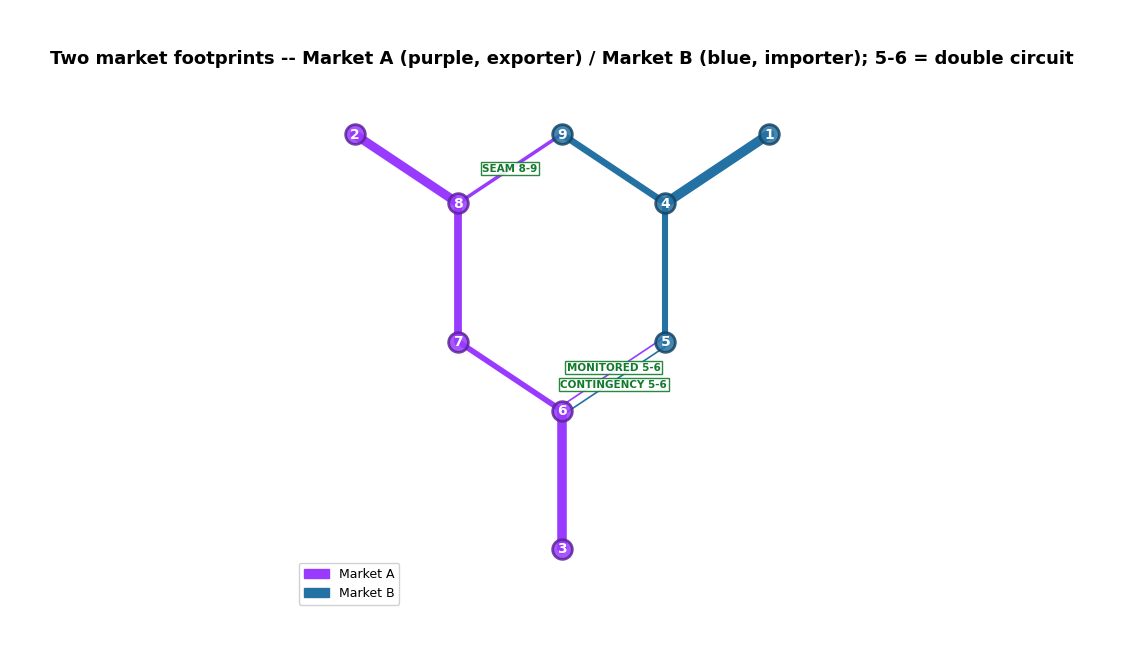

In [5]:
# Configuration map: the two market footprints on the shared grid. The 5-6 corridor is a
# parallel double circuit (one per market); the 8-9 tie is the alternate path. Buses are
# coloured by market, lines by the market that monitors them; seams grey. Edit MKT_DEFS
# / MONITORED_LINES above and re-run to reshape.
import matplotlib.patches as mpatches
_bcol = {b: MARKET_COLORS[mkt_of(b)] for b in pt.buses}
fig, ax = plot_network_topology(
    build_network(), supply_by_bus={}, demand_by_bus={}, bus_colors=_bcol, bus_coords=COORDS,
    line_flows={l: 0.0 for l in pt.lines}, line_widths=susceptance_widths(pt),
    line_colors=market_line_colors(pt),
    title='Two market footprints -- Market A (purple, exporter) / Market B (blue, importer); 5-6 = double circuit')
for _l in seam_lines:
    _b0, _b1 = pt.line_buses[pt.line_idx[_l]]
    _x0, _y0 = COORDS[_b0]; _x1, _y1 = COORDS[_b1]
    _tag = 'CONTINGENCY 5-6' if _l == 'line_2_ba2' else ('MONITORED 5-6' if _l == 'line_2_ba1' else f'SEAM {_b0}-{_b1}')
    ax.text((_x0 + _x1) / 2, (_y0 + _y1) / 2 + (0.12 if _l == 'line_2_ba1' else -0.12 if _l == 'line_2_ba2' else 0),
            _tag, fontsize=7.5, fontweight='bold', color='#117A2B', ha='center', va='center',
            bbox=dict(fc='white', ec='#117A2B', alpha=0.9, pad=1.2), zorder=7)
ax.legend(handles=[mpatches.Patch(color=MARKET_COLORS[m], label=m) for m in MKT_DEFS],
          loc='lower left', fontsize=9, framealpha=0.9)
plt.show()

## 2. A contingency in the other market

Market B imports its load as cheap Market A energy -- a privately rational schedule that
loads the shared 5-6 corridor. The corridor's two circuits share it evenly, so losing
Market B's circuit throws most of it onto Market A's survivor:

$$F^{\text{post}}_{\text{A}} = F_{\text{A}} + \text{LODF}\cdot F_{\text{B}}
  = (1+\text{LODF})\,F_{\text{A}},\qquad \text{LODF}\approx 0.6, \qquad (3)$$

with the remaining flow rerouting onto the 8-9 tie. Market A's **N-1** rule holds its
circuit low enough that post-contingency it lands at the 75 MW rating:

$$F_{\text{A}} \le \frac{\bar F_{\text{A}}}{1+\text{LODF}} \approx 47\ \text{MW}. \qquad (4)$$

The corridor is loaded by **Market B's import** and would be relieved most cheaply by
**Market B's own generation** -- both outside Market A's dispatch. That is the whole
problem.

In [6]:
# Market B's generic self-schedule (it imports its whole load from Market A), and the
# contingency: lose Market B's circuit (line_2_ba2) -> its flow lands on Market A's.
GENERIC_IMPORT = float(sum(LOADS[b] for b in MKT_DEFS['Market B'] if b in LOADS))   # 215 MW
CIRCUIT_MW = float(build_network().lines.loc['line_2_ba1', 's_nom'])               # 75 MW per circuit

def B_self_schedule(E):
    # Market B's net exogenous injection {bus: MW}: its own units serve its load minus the
    # import E it buys from Market A, summing to -E -- what it presents to Market A's clear.
    exo = {b: -float(LOADS[b]) for b in MKT_DEFS['Market B'] if b in LOADS}
    need = sum(float(LOADS[b]) for b in MKT_DEFS['Market B'] if b in LOADS) - E
    for g, s in sorted(((g, s) for g, s in GEN_FLEET.items() if mkt_of(s['bus']) == 'Market B'),
                       key=lambda kv: kv[1]['cost']):
        take = max(0.0, min(need, s['p_nom'])); need -= take
        exo[s['bus']] = exo.get(s['bus'], 0.0) + take
    return exo

# post-contingency operator: remove Market B's circuit, same injections, no redispatch.
_nctg = build_network(); _nctg.remove('Line', 'line_2_ba2'); pt_ctg = compute_ptdf(_nctg, slack_bus='1')
def post_ctg(res, line='line_2_ba1'):
    return float((pt_ctg.ptdf @ res.injection)[pt_ctg.line_idx[line]])

# Market A manages the corridor: it optimises its own resources with Market B's schedule
# fixed as exo, monitoring its lines (+ the tie). flow_offsets reserves N-1 headroom.
def A_clear(ratings=None, E=GENERIC_IMPORT, offsets=None):
    n = build_network(ratings or {}); p = compute_ptdf(n, slack_bus='1')
    e = make_engine('Market A', MKT_DEFS['Market A'], activated=MONITORED_LINES['Market A'])
    r = solve_engine_dispatch(p, e, exo=B_self_schedule(E), flow_offsets=offsets, shed_price=SHED_PRICE)
    return n, p, e, r

def U_clear(ratings=None):
    n = build_network(ratings or {}); p = compute_ptdf(n, slack_bus='1')
    e = make_engine('Unified', buses=pt.buses, activated='all')
    return n, p, e, solve_engine_dispatch(p, e, shed_price=SHED_PRICE)

def A_export_sources(rA_econ):
    # Which Market A generator buses source the export to B: A serves its OWN load from its
    # cheapest generation first, and each unit's remaining dispatch (cheap-first) is export.
    # Returns {A bus: exported MW}; the values sum to the interchange E.
    local = sum(float(LOADS[b]) for b in MKT_DEFS['Market A'] if b in LOADS)
    src = {}
    for g, s in sorted(GEN_FLEET.items(), key=lambda kv: kv[1]['cost']):
        b = s['bus']
        if mkt_of(b) != 'Market A':
            continue
        disp = rA_econ.gen_by_bus.get(b, 0.0)
        serve = min(disp, local); local -= serve
        if disp - serve > 0.01:
            src[b] = src.get(b, 0.0) + (disp - serve)
    return src

def B_view(E):
    # Market B's own view: it imports E from Market A as a price-taking SELF-SCHEDULE, SOURCED
    # at the Market A generator buses that export it (B carries the full path -- the injection
    # lands on A's nodes and reaches B's load through the network, the seams-notebook trade
    # convention), not as a block at B's seam bus. A self-schedule names no price, so it never
    # SETS one; B's own $50 unit prices B's clear. If the import would cover B's whole load the
    # clear is degenerate (no B unit on the margin), so trim it by EPS so B's next resource
    # fills the sliver and that unit ($50) sets B's marginal price.
    EPS = 0.25
    src = A_export_sources(rEcon)
    tot = sum(src.values()) or 1.0
    f = max(tot - EPS, 0.0) / tot
    exo = {b: v * f for b, v in src.items()}
    e = make_engine('Market B', MKT_DEFS['Market B'], activated=MONITORED_LINES['Market B'])
    return e, solve_engine_dispatch(pt, e, exo=exo, shed_price=SHED_PRICE), exo

def syscost(res, E=None):
    pc = sum(COST.get(b, 0.0) * res.gen_by_bus.get(b, 0.0) for b in pt.buses)
    if E is not None:
        ex = B_self_schedule(E)
        pc += sum(COST.get(b, 0.0) * max(0.0, ex.get(b, 0.0)) for b in MKT_DEFS['Market B'])
    return pc

# the economic clear (N-1 not yet imposed) -> measure LODF and the N-1 de-rate.
_, _, _, rEcon = A_clear({})
LODF = post_ctg(rEcon) / rEcon.flow_own['line_2_ba1'] - 1.0
DERATE_N1 = CIRCUIT_MW / (1.0 + LODF)
ctg_tbl = pd.DataFrame({
    'rating (MW)':           {'line_2_ba1': CIRCUIT_MW, 'line_2_ba2': CIRCUIT_MW},
    'base flow (MW)':        {'line_2_ba1': round(rEcon.flow_own['line_2_ba1'], 0),
                              'line_2_ba2': round(rEcon.flow_own['line_2_ba2'], 0)},
    'post-contingency (MW)': {'line_2_ba1': round(post_ctg(rEcon), 0), 'line_2_ba2': 0.0},
    'overload?':             {'line_2_ba1': abs(post_ctg(rEcon)) > CIRCUIT_MW, 'line_2_ba2': False},
})
print(f'Market B imports its whole {GENERIC_IMPORT:.0f} MW load from Market A.')
display(ctg_tbl)
print(f'LODF (line_2_ba2 -> line_2_ba1) = {LODF:.2f};  N-1 rule: Market A holds line_2_ba1 '
      f'<= {DERATE_N1:.1f} MW so post-contingency it lands at {CIRCUIT_MW:.0f}.')

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


Market B imports its whole 215 MW load from Market A.

,rating (MW),base flow (MW),post-contingency (MW),overload?
line_2_ba1,75.0,-53.0,-85.0,True
line_2_ba2,75.0,-53.0,0.0,False


LODF (line_2_ba2 -> line_2_ba1) = 0.60;  N-1 rule: Market A holds line_2_ba1 <= 46.9 MW so post-contingency it lands at 75.

In [7]:
# One example = the four views of the shared grid. Market A (its managing clear, Market B
# greyed); Market B (its self-schedule import); Combined (the actual wire, each bus at its
# home LMP, the contingency annotated); Unified (one engine over every bus).
def four_views(net, ptx, engA, rA, tag, rU_pack=None, E=GENERIC_IMPORT):
    post = post_ctg(rA); secure = abs(post) <= CIRCUIT_MW + 0.1
    ctg_note = f'line_2_ba1 base {abs(rA.flow_own["line_2_ba1"]):.0f} -> post-contingency {abs(post):.0f}/{CIRCUIT_MW:.0f}'
    # (1) Market A -- the managing clear. When A clears B's import as a fixed exo schedule
    # (the BLIND/ACCOMMODATED views) B's load buses are not in A's engine, so the wheeled
    # export is invisible: A's supply (its full dispatch) exceeds the drawn demand (its own
    # load) and the gen->load chords trace only that internal load. Redraw the export as the
    # self-schedule it is -- (greyed) demand at B's sink buses -- so supply = demand and the
    # chords trace the full dispatch. The UNIFIED view's engine already carries B's load, so
    # skip it there (else demand double-counts); the 0 MW entries are dropped so no empty bar.
    a_manages = not any(b in engA.loads for b in MKT_DEFS['Market B'])
    figs.footprint_figure(net, ptx, fp, engA, rA, highlight='Market A', dim_buses=MKT_DEFS['Market B'],
                          exo_sched=({b: mw for b, mw in B_self_schedule(E).items() if abs(mw) > 1e-6}
                                     if a_manages else None),
                          suptitle=f'{tag} | Market A -- manages the corridor   ({ctg_note}, {"secure" if secure else "OVERLOAD"})')
    plt.show()
    # (2) Market B -- imports E from A as a price-taking self-schedule, SOURCED at the Market A
    # generator buses that export it (grey, drawn at A's LMP -- the price B settles the import
    # at there); it reaches B's loads through the network, and B's own $50 unit prices B's
    # clear. The gap from each grey bar up to the dashed B-LMP line is the seam dual gap.
    engB, rB, exoB = B_view(E)
    supB, demB = to_supply_demand(engB, rB)
    for _b, _mw in exoB.items():
        supB.setdefault(_b, []).insert(0, {'unit_id': 'self_schedule', 'price': rEcon.lmp[_b],
                                           'volume': _mw, 'capacity': _mw, 'accepted_volume': _mw,
                                           'color': '#95A5A6'})
    figs.footprint_figure(net, ptx, fp, engB, rB, highlight='Market B', dim_buses=MKT_DEFS['Market A'],
                          sup_dem=(supB, demB), exo_sched=exoB,
                          legend_note='Self-schedule import: sourced at Market A buses, drawn at A LMP (gap to dashed B-LMP = seam rent)',
                          suptitle=f'{tag} | Market B -- imports {E:.0f} MW from Market A at \${rEcon.energy_price:.0f} (its own \$50 unit is marginal); the contingency is its circuit')
    plt.show()
    # (3) Combined -- the actual wire (A's clear already carries B's schedule), contingency drawn.
    # A's gens cover A's load + the E export; add Market B's loads so the wheel balances
    # (at E = B's load, A's generation exactly equals the combined load).
    supC, demC = to_supply_demand(engA, rA)
    for b in MKT_DEFS['Market B']:
        if b in LOADS: demC[b] = demC.get(b, 0.0) + float(LOADS[b])
    over = {l for l in ptx.lines if abs(rA.flow_own[l]) > ptx.s_nom[ptx.line_idx[l]] + 1e-6}
    fig, _ = plot_combined_letter(
        net, supC, demC, bus_colors=dict(BUS_COLORS), bus_lmps=rA.lmp,
        line_flows={l: rA.flow_own[l] for l in ptx.lines},
        line_widths=susceptance_widths(ptx), line_colors=market_line_colors(ptx),
        constrained_lines=over, flows=nodal_plot.compute_ptdf_flows(net, supC, demC),
        lmp_line=True, bus_groups=MKT_GROUPS, group_colors=dict(MARKET_COLORS), show_group_labels=False,
        all_buses=ptx.buses, sector_order=RING_ORDER, bus_coords=COORDS, center_bus=CENTER_BUS,
        annotate_roles=True, axis_key=True,
        title_left='Network -- the one wire under both schedules',
        suptitle=f'{tag} | Combined -- {ctg_note}  ({"secure" if secure else "POST-CONTINGENCY OVERLOAD"})')
    plt.show()
    # (4) Unified -- one engine co-optimises both.
    if rU_pack is None:
        rU_pack = U_clear({'line_2_ba1': DERATE_N1})
    nU, pU, eU, rU = rU_pack
    figs.footprint_figure(nU, pU, fp, eU, rU,
                          suptitle=f'{tag} | Unified -- co-optimised benchmark   (energy \${rU.energy_price:.0f}/MWh)')
    plt.show()
    return rB

print('four_views(net, pt, engA, rA, tag) ready')

four_views(net, pt, engA, rA, tag) ready

## 3. Blind clearing -- the interference

Market A honours Market B's import schedule and dispatches economically, with **no N-1
limit** on its circuit. Each market's own clear is feasible, but the **actual** corridor
flow -- which neither market sees in full -- is large, and when Market B's circuit trips
the survivor **overloads**. The four views: Market A and Market B each look fine, the
Combined wire shows the post-contingency violation, and the Unified clear (economic) would
violate it too.

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


Blind/economic: Market A serves the 215 MW import at production cost $8,475/h.

  base line_2_ba1 = -53/75  ->  POST-CONTINGENCY -85/75  --  N-1 VIOLATION

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


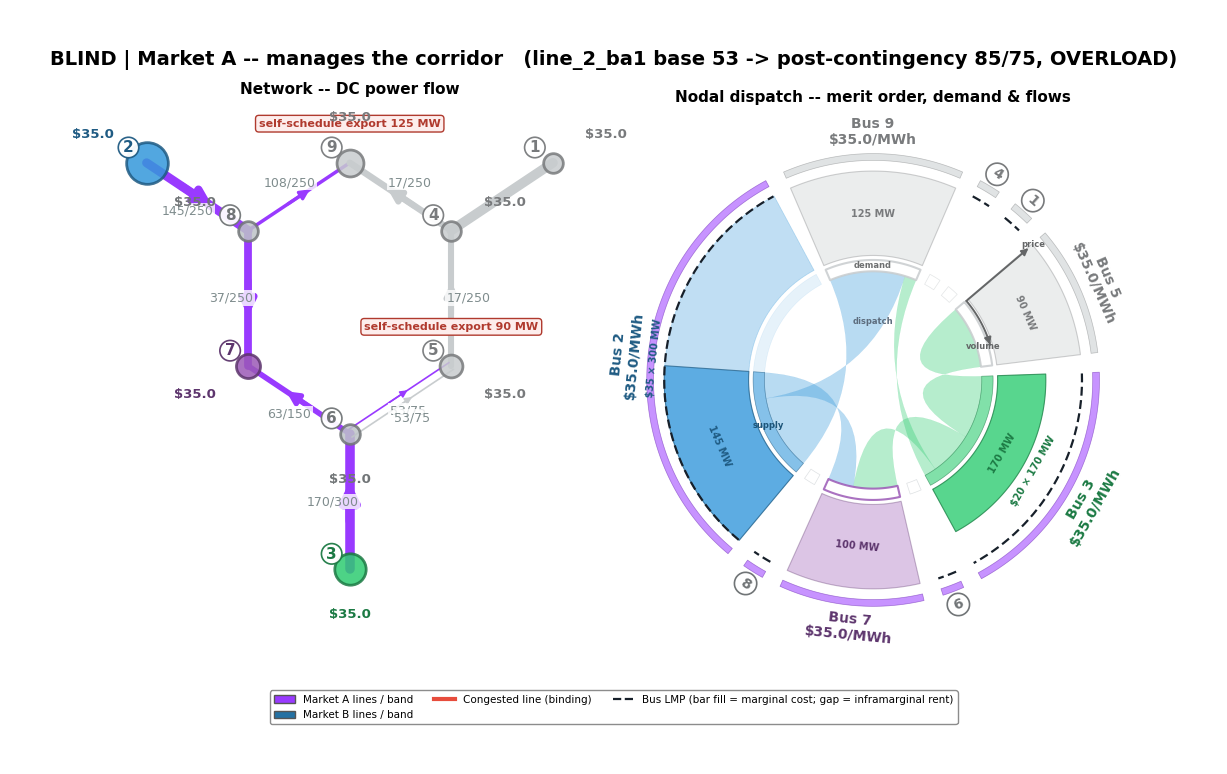

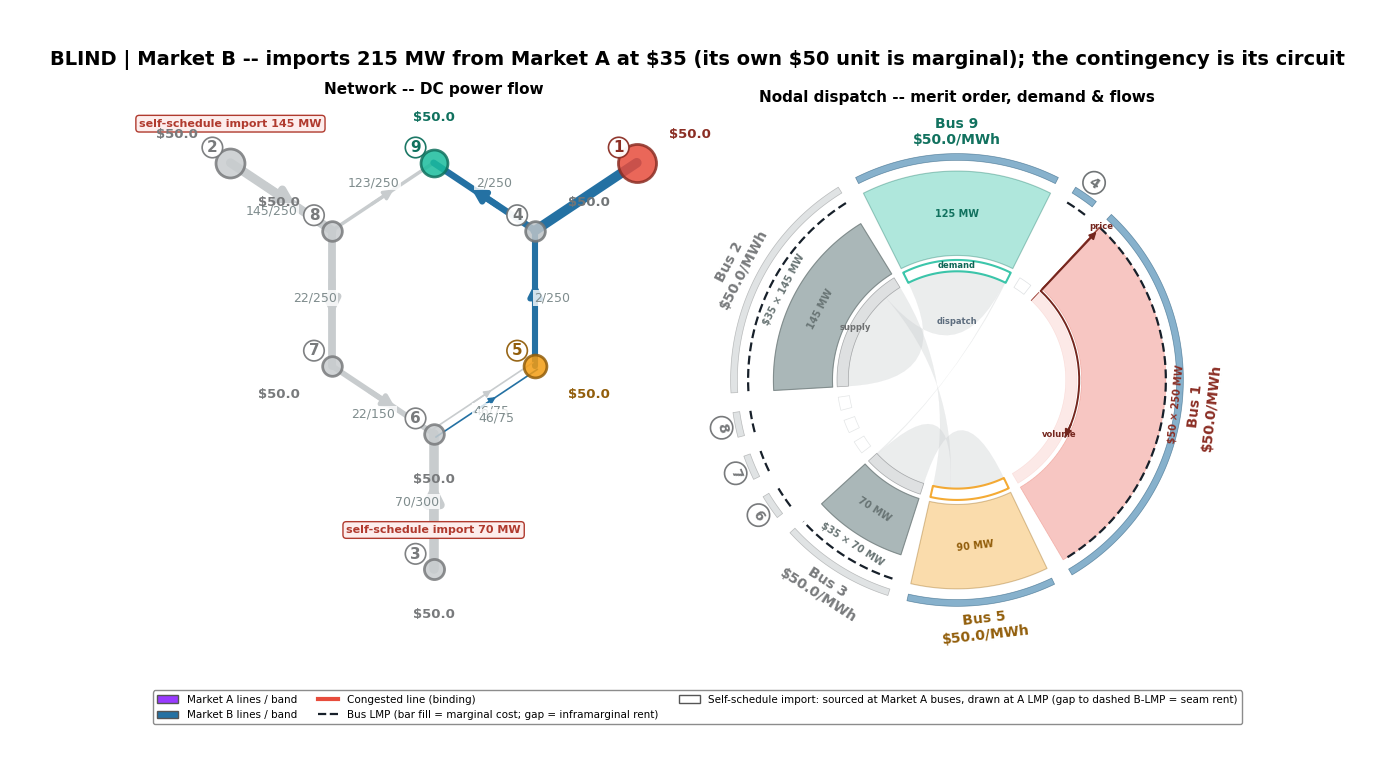

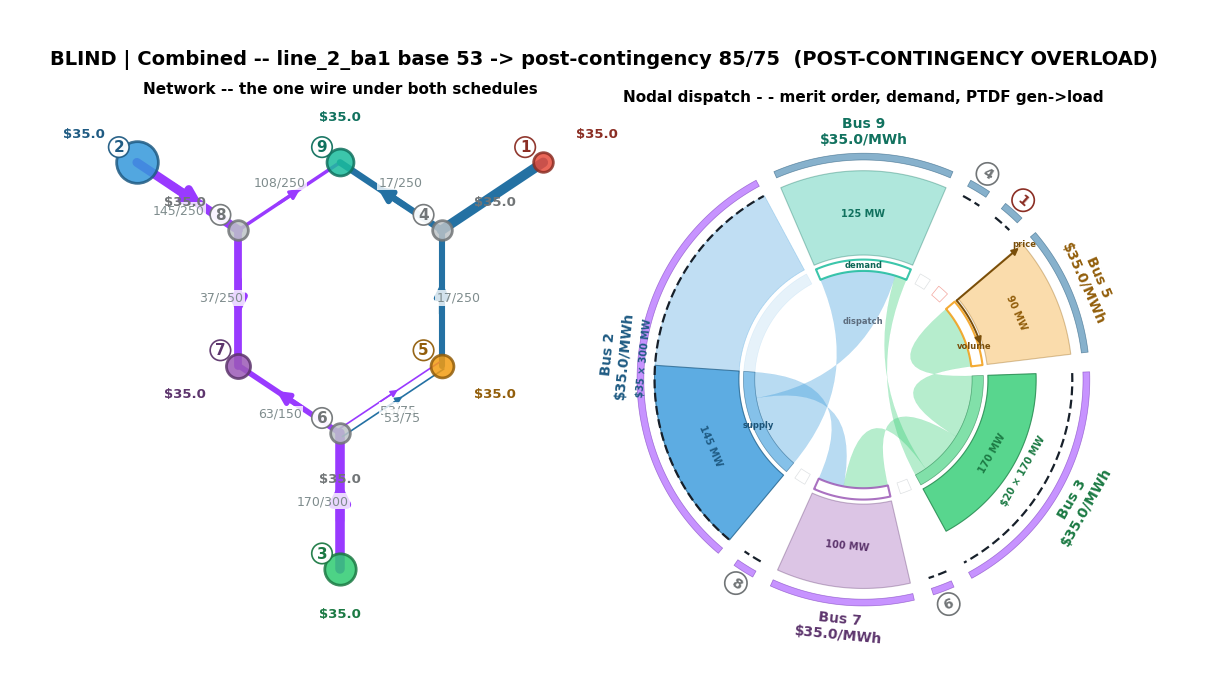

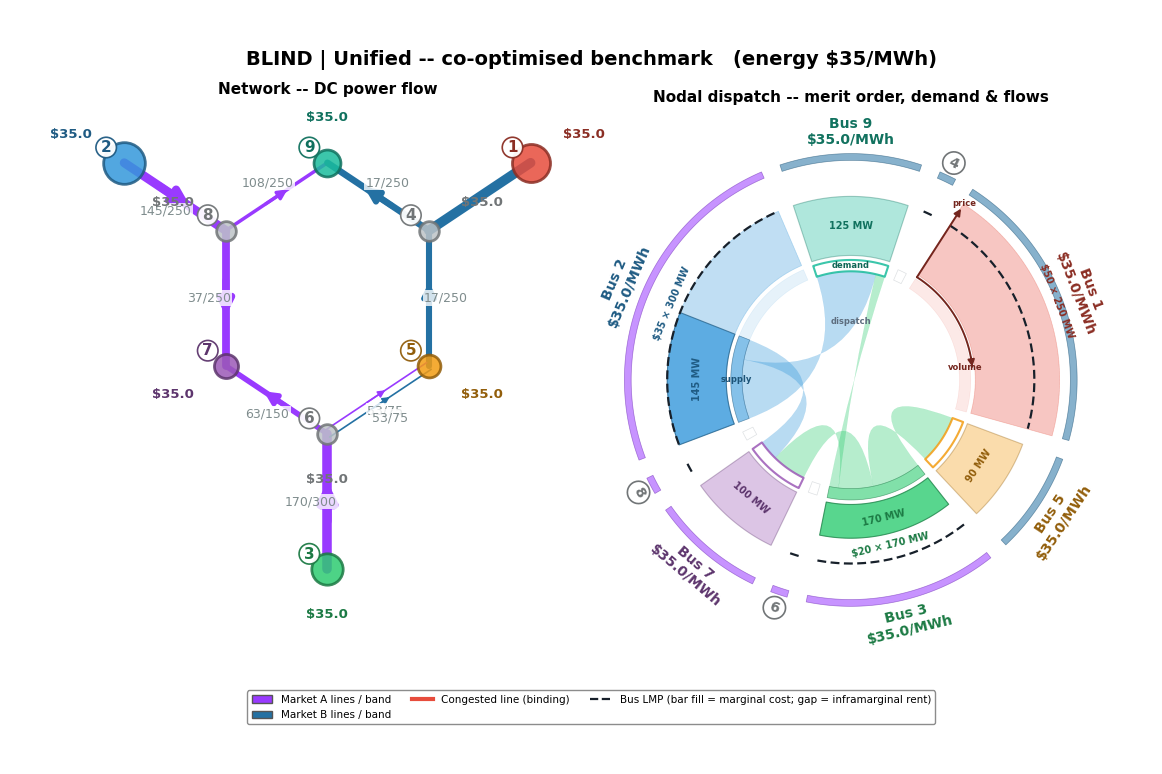

EngineResult(name='Market B', dispatch={'gen_slack_0': 0.25}, gen_by_bus={'1': np.float64(0.25)}, load_by_bus={'5': 90.0, '9': 125.0}, exo_by_bus={'3': 69.9186046511628, '2': 144.83139534883722}, injection=array([   0.25      ,  144.83139535,   69.91860465,    0.        ,
        -90.        ,    0.        ,    0.        ,    0.        ,
       -125.        ]), lmp={'1': np.float64(50.0), '2': np.float64(50.0), '3': np.float64(50.0), '4': np.float64(50.0), '5': np.float64(50.0), '6': np.float64(50.0), '7': np.float64(50.0), '8': np.float64(50.0), '9': np.float64(50.0)}, energy_price=50.0, line_dual={'line_0': 0.0, 'line_1': 0.0, 'line_3': 0.0, 'line_4': 0.0, 'line_5': 0.0, 'line_6': 0.0, 'line_7': 0.0, 'line_8': 0.0, 'line_2_ba1': 0.0, 'line_2_ba2': 0.0}, flow_own={'line_0': 0.25000000000005684, 'line_1': -1.899874976088281, 'line_3': 69.91860465116278, 'line_4': -21.981270324925525, 'line_5': -21.98127032492557, 'line_6': -144.83139534883708, 'line_7': 122.85012502391163, 'line_8': -2

In [8]:
nE, pE, eE, rE = A_clear({})            # economic: honour the import, no N-1
ECON_COST = syscost(rE, E=GENERIC_IMPORT)
print(f'Blind/economic: Market A serves the {GENERIC_IMPORT:.0f} MW import at production cost ${ECON_COST:,.0f}/h.')
print(f'  base line_2_ba1 = {rE.flow_own["line_2_ba1"]:.0f}/{CIRCUIT_MW:.0f}  ->  POST-CONTINGENCY '
      f'{post_ctg(rE):.0f}/{CIRCUIT_MW:.0f}  --  {"N-1 VIOLATION" if abs(post_ctg(rE)) > CIRCUIT_MW else "ok"}')
four_views(nE, pE, eE, rE, 'BLIND', rU_pack=U_clear({}))

## 4. Inefficient accommodation

Market A cannot dispatch Market B, so to restore N-1 it does what an Available Transfer
Capability process does: it **reserves headroom** on its circuit, sized from a forecast of
the post-contingency increment times a margin, and clears its own resources against the
reduced limit:

$$|F^{A}_m| + \widehat G_m \le \bar F_m,\qquad \widehat G_m = \beta\,\text{LODF}\,F^{\mathrm{ref}},
  \quad \beta\ge 1,\quad m=\texttt{line\_2\_ba1}. \qquad (5)$$

It works -- the post-contingency wire is safe -- but Market A reroutes through the 8-9 tie
with **only its own resources**, a more expensive dispatch than coordination would need.
Reserve from the economic forecast and it over-reserves (the economic flow is higher than
the secure circuit actually carries); reserve too much and it cannot serve the schedule at
all.

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


Market A reserves 32 MW on line_2_ba1 (LODF 0.60 x forecast 53 x margin 1.00).

  base line_2_ba1 = -42.9  ->  post-contingency -69/75 (secure);  production cost $9,713/h.

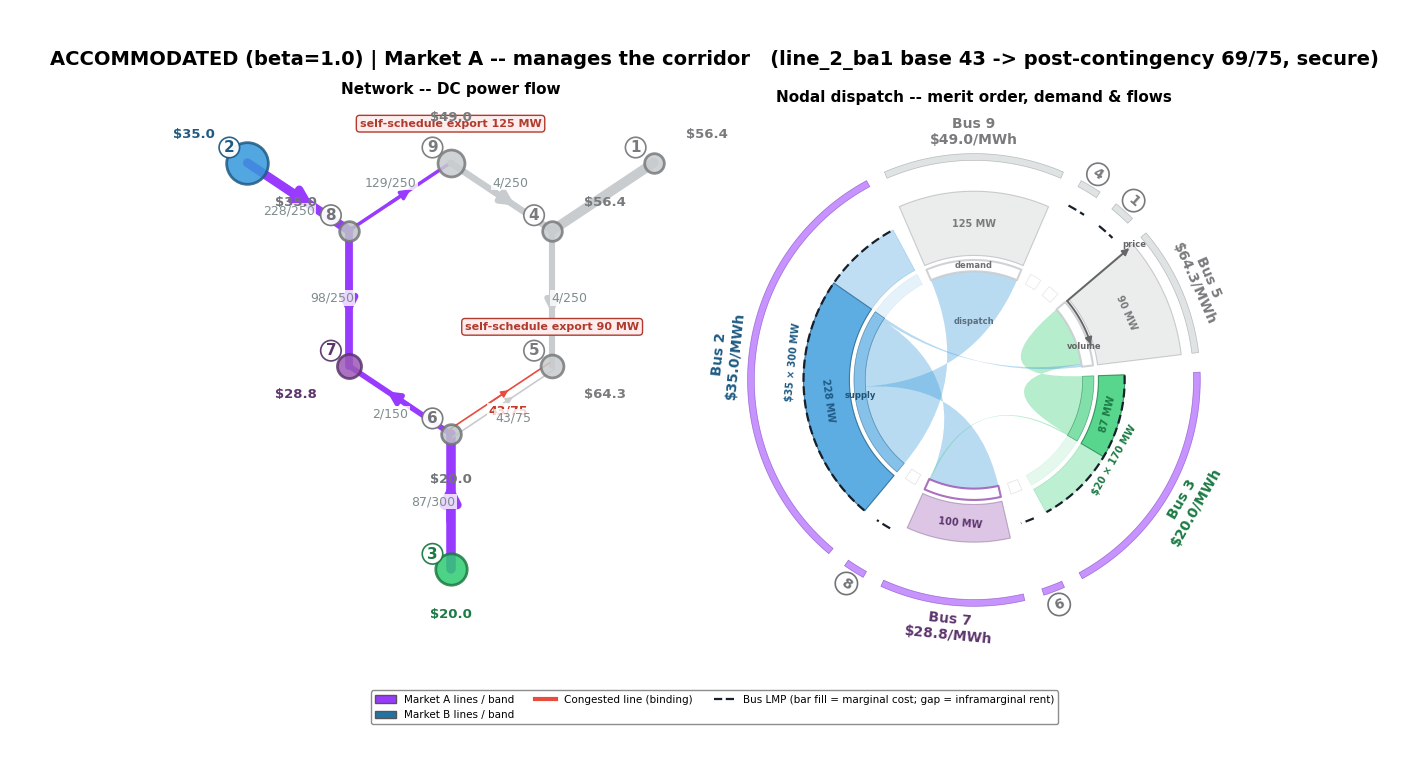

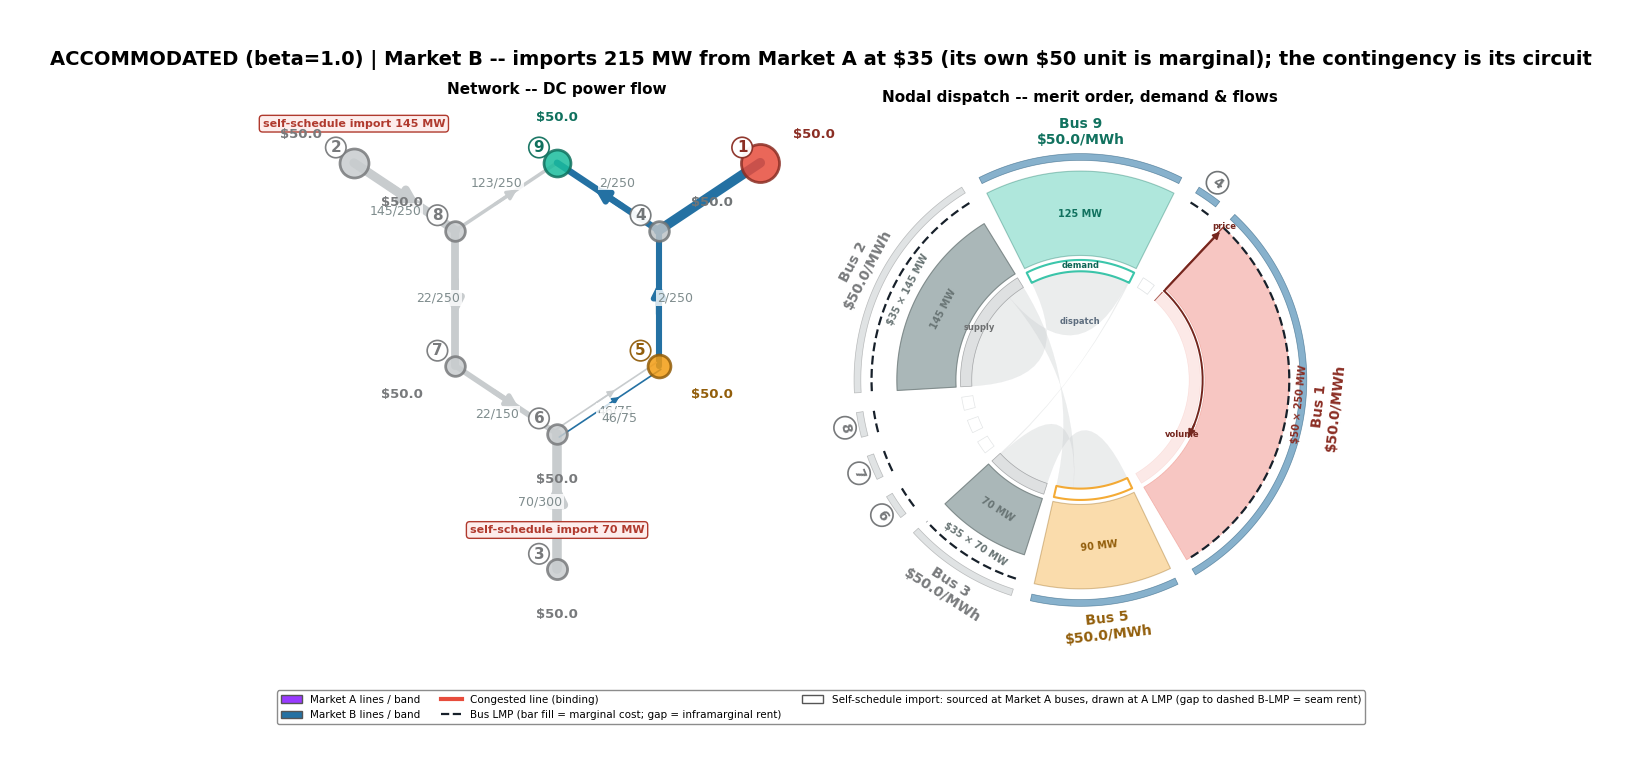

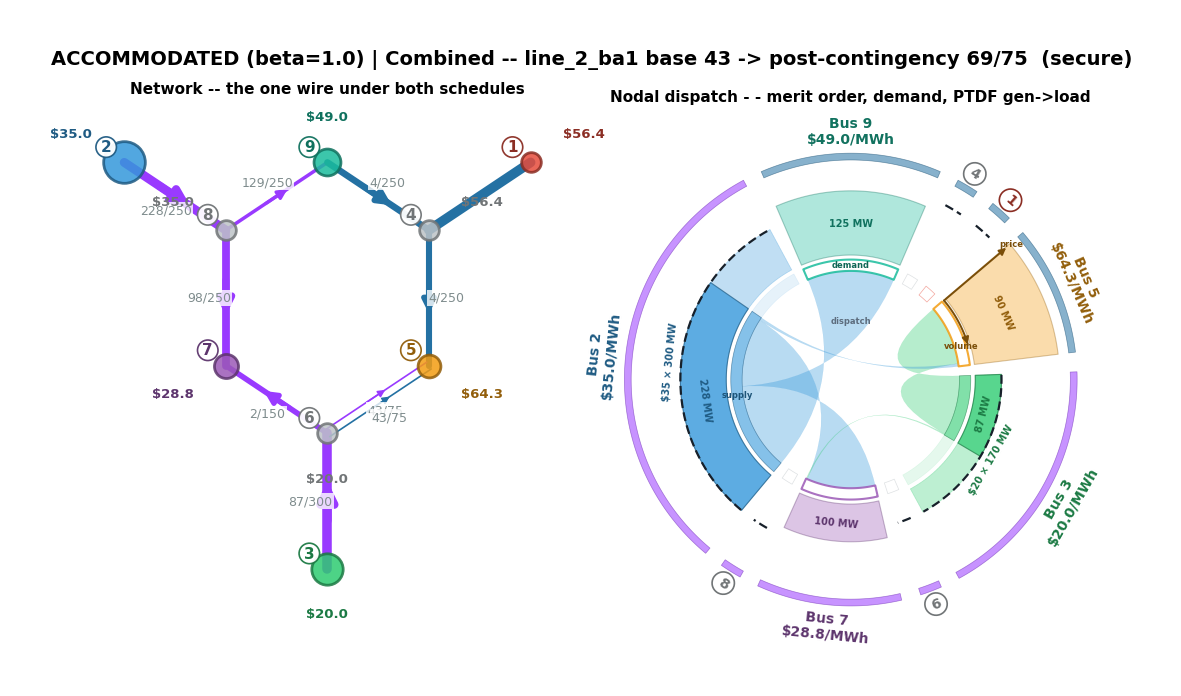

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


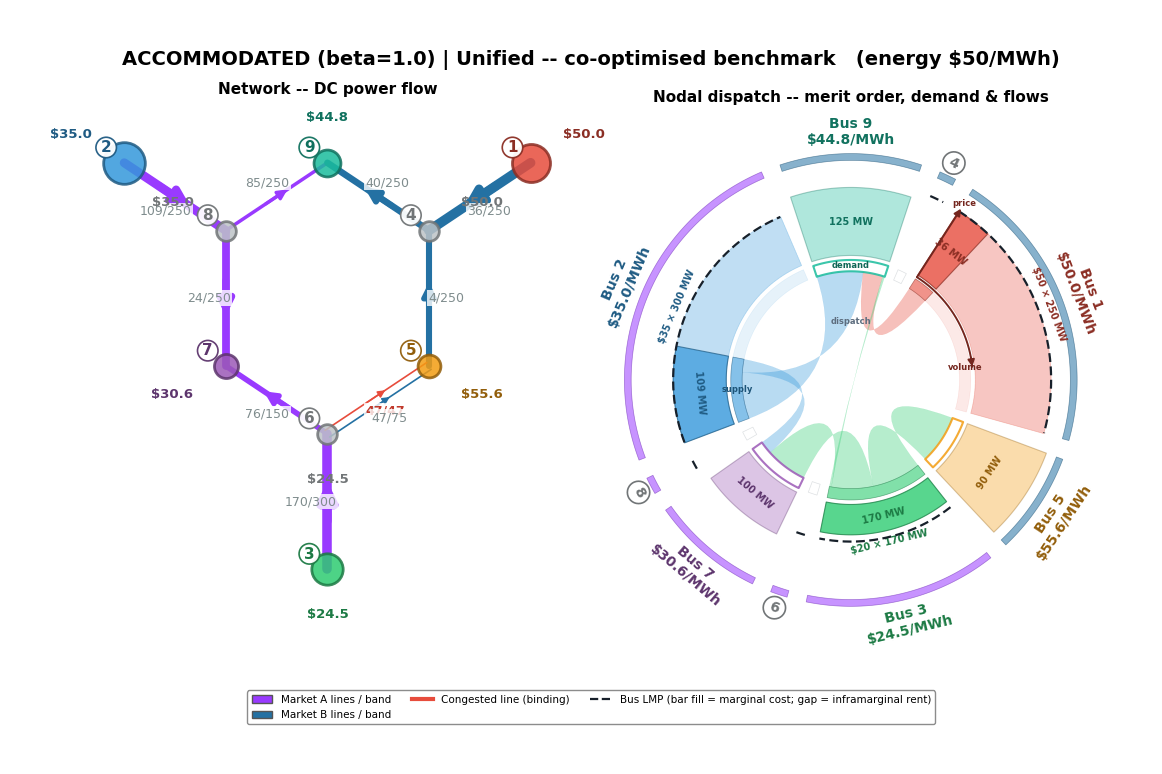

EngineResult(name='Market B', dispatch={'gen_slack_0': 0.25}, gen_by_bus={'1': np.float64(0.25)}, load_by_bus={'5': 90.0, '9': 125.0}, exo_by_bus={'3': 69.9186046511628, '2': 144.83139534883722}, injection=array([   0.25      ,  144.83139535,   69.91860465,    0.        ,
        -90.        ,    0.        ,    0.        ,    0.        ,
       -125.        ]), lmp={'1': np.float64(50.0), '2': np.float64(50.0), '3': np.float64(50.0), '4': np.float64(50.0), '5': np.float64(50.0), '6': np.float64(50.0), '7': np.float64(50.0), '8': np.float64(50.0), '9': np.float64(50.0)}, energy_price=50.0, line_dual={'line_0': 0.0, 'line_1': 0.0, 'line_3': 0.0, 'line_4': 0.0, 'line_5': 0.0, 'line_6': 0.0, 'line_7': 0.0, 'line_8': 0.0, 'line_2_ba1': 0.0, 'line_2_ba2': 0.0}, flow_own={'line_0': 0.25000000000005684, 'line_1': -1.899874976088281, 'line_3': 69.91860465116278, 'line_4': -21.981270324925525, 'line_5': -21.98127032492557, 'line_6': -144.83139534883708, 'line_7': 122.85012502391163, 'line_8': -2

In [9]:
# -- EDIT -- the reservation Market A makes for the contingency
ATC_MARGIN = 1.0     # beta: 1.0 reserves exactly the forecast post-contingency increment
# ---------------------------------------------------------------------------
Fref = abs(rEcon.flow_own['line_2_ba1'])     # forecast = the circuit's economic loading
def accommodate(beta):
    off = {'line_2_ba1': -beta * LODF * Fref}
    return A_clear({}, offsets=off)
nA, pA, eA, rA = accommodate(ATC_MARGIN)
ACC_COST = syscost(rA, E=GENERIC_IMPORT)
print(f'Market A reserves {ATC_MARGIN * LODF * Fref:.0f} MW on line_2_ba1 '
      f'(LODF {LODF:.2f} x forecast {Fref:.0f} x margin {ATC_MARGIN:.2f}).')
print(f'  base line_2_ba1 = {rA.flow_own["line_2_ba1"]:.1f}  ->  post-contingency '
      f'{post_ctg(rA):.0f}/{CIRCUIT_MW:.0f} (secure);  production cost ${ACC_COST:,.0f}/h.')
four_views(nA, pA, eA, rA, f'ACCOMMODATED (beta={ATC_MARGIN:.1f})')

In [10]:
# The price of conservatism: sweep the margin and watch security and cost move.
rows = []
for beta in [0.0, 0.75, 1.0, 1.25, 1.5]:
    try:
        _, _, _, r = accommodate(beta)
        post = abs(post_ctg(r)); shed = sum(r.shed_by_bus.values())
        rows.append({'margin beta': beta, 'reserved (MW)': round(beta * LODF * Fref),
                     'line_2_ba1 base (MW)': round(abs(r.flow_own['line_2_ba1'])),
                     'post-contingency (MW)': round(post),
                     'secure?': 'yes' if post <= CIRCUIT_MW + 0.1 else 'NO -- overload',
                     'shed (MW)': round(shed),
                     'cost ($/h)': round(syscost(r, E=GENERIC_IMPORT))})
    except RuntimeError:
        rows.append({'margin beta': beta, 'reserved (MW)': round(beta * LODF * Fref),
                     'line_2_ba1 base (MW)': '--', 'post-contingency (MW)': '--',
                     'secure?': 'INFEASIBLE -- cannot serve the import', 'shed (MW)': '--', 'cost ($/h)': None})
display(pd.DataFrame(rows).set_index('margin beta'))

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


,reserved (MW),line_2_ba1 base (MW),post-contingency (MW),secure?,shed (MW),cost ($/h)
margin beta,,,,,,
0.00,0,53,85,NO -- overload,0,8475.0
0.75,24,51,82,NO -- overload,0,8765.0
1.00,32,43,69,yes,0,9713.0
1.25,40,--,--,INFEASIBLE -- cannot serve the import,--,NaN
1.50,48,--,--,INFEASIBLE -- cannot serve the import,--,NaN


## 5. Coordination -- the unified clearing

One clearing co-optimises both markets. It does the thing the separate markets could not:
it **ramps Market B's own unit** so Market B self-supplies more and imports less, the
corridor falls below the N-1 limit, and the **same reliability standard is met at a lower
production cost**. The binding circuit prices out, the border separates, and Market B
settles in the unified clear. The cost gap between accommodation and coordination is the
value of making Market B's resources endogenous.

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


Coordinated: Market B's unit ramps to 36 MW (self-supplies, imports less);

  base line_2_ba1 = -46.9  ->  post-contingency -75/75 (secure);  production cost $9,018/h.

  cost ladder:  blind/economic $8,475 (overloads)  ->  coordinated $9,018  ->  accommodated (beta=1.0) $9,713.

  value of coordination over accommodation = $695/h.

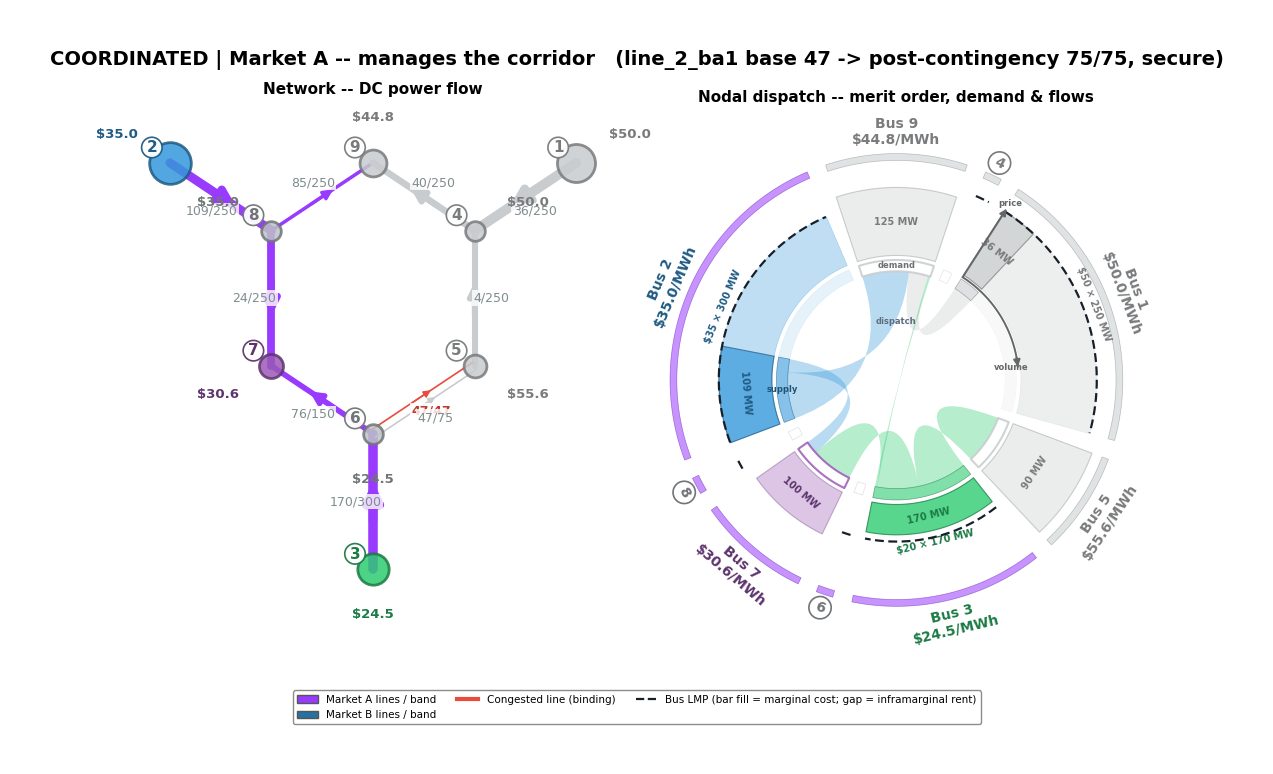

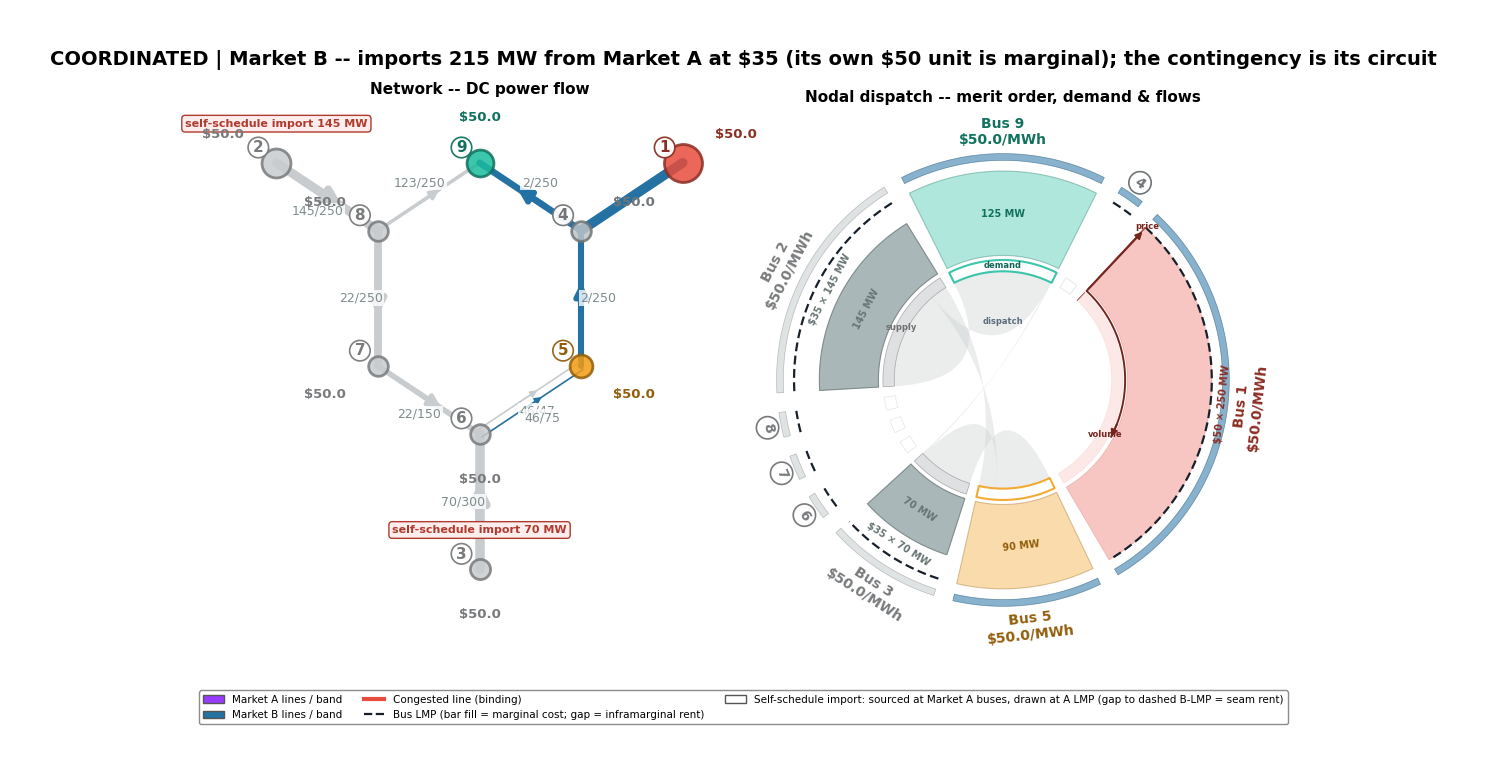

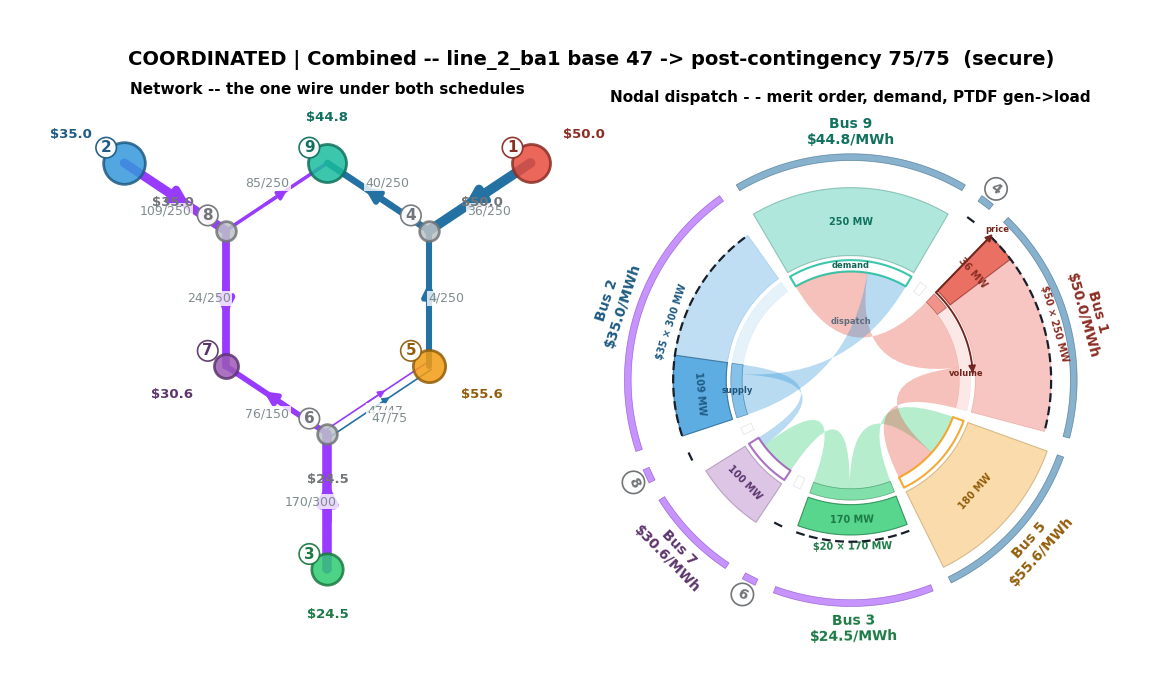

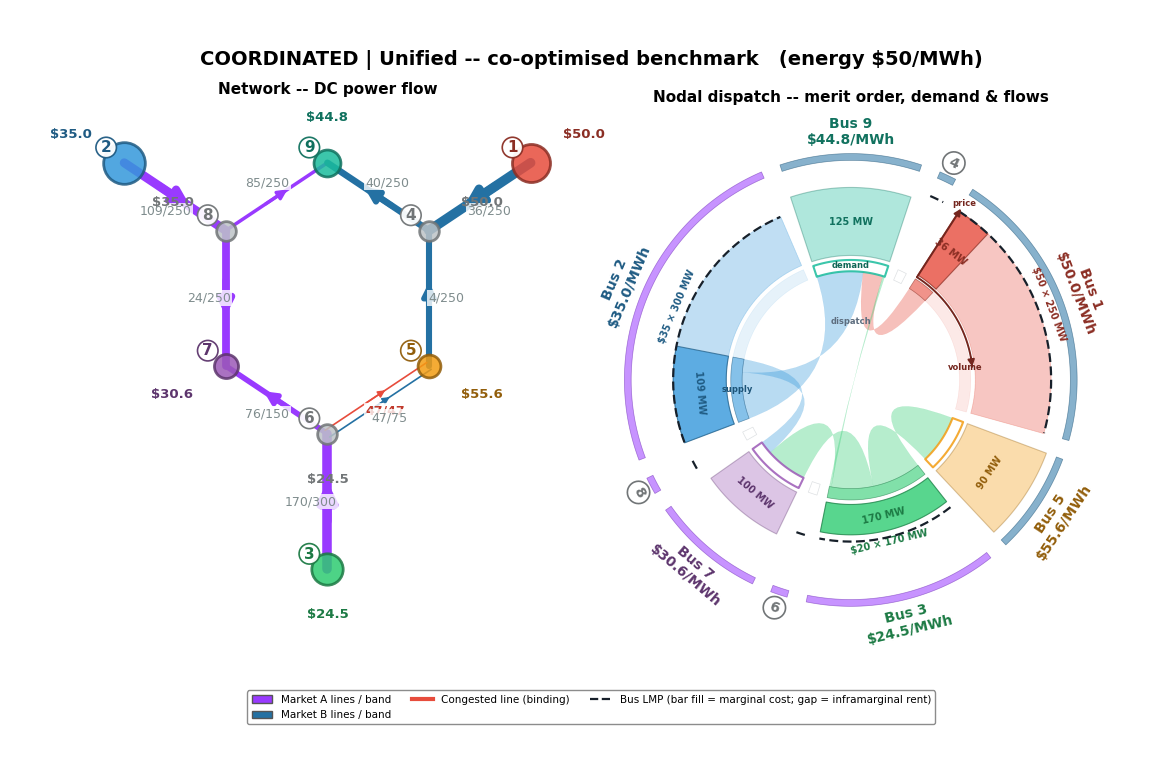

EngineResult(name='Market B', dispatch={'gen_slack_0': 0.25}, gen_by_bus={'1': np.float64(0.25)}, load_by_bus={'5': 90.0, '9': 125.0}, exo_by_bus={'3': 69.9186046511628, '2': 144.83139534883722}, injection=array([   0.25      ,  144.83139535,   69.91860465,    0.        ,
        -90.        ,    0.        ,    0.        ,    0.        ,
       -125.        ]), lmp={'1': np.float64(50.0), '2': np.float64(50.0), '3': np.float64(50.0), '4': np.float64(50.0), '5': np.float64(50.0), '6': np.float64(50.0), '7': np.float64(50.0), '8': np.float64(50.0), '9': np.float64(50.0)}, energy_price=50.0, line_dual={'line_0': 0.0, 'line_1': 0.0, 'line_3': 0.0, 'line_4': 0.0, 'line_5': 0.0, 'line_6': 0.0, 'line_7': 0.0, 'line_8': 0.0, 'line_2_ba1': 0.0, 'line_2_ba2': 0.0}, flow_own={'line_0': 0.25000000000005684, 'line_1': -1.899874976088281, 'line_3': 69.91860465116278, 'line_4': -21.981270324925525, 'line_5': -21.98127032492557, 'line_6': -144.83139534883708, 'line_7': 122.85012502391163, 'line_8': -2

In [11]:
nU, pU, eU, rU = U_clear({'line_2_ba1': DERATE_N1})
COORD_COST = syscost(rU)
print(f"Coordinated: Market B's unit ramps to {rU.gen_by_bus.get('1', 0):.0f} MW (self-supplies, imports less);")
print(f'  base line_2_ba1 = {rU.flow_own["line_2_ba1"]:.1f}  ->  post-contingency '
      f'{post_ctg(rU):.0f}/{CIRCUIT_MW:.0f} (secure);  production cost ${COORD_COST:,.0f}/h.')
print(f'  cost ladder:  blind/economic ${ECON_COST:,.0f} (overloads)  ->  coordinated ${COORD_COST:,.0f}  '
      f'->  accommodated (beta={ATC_MARGIN:.1f}) ${ACC_COST:,.0f}.')
print(f'  value of coordination over accommodation = ${ACC_COST - COORD_COST:,.0f}/h.')
four_views(nU, pU, eU, rU, 'COORDINATED', rU_pack=(nU, pU, eU, rU))

## 6. Settlement and the position ledger

Three arrangements, settled at each one's own prices. The cross-market **position ledger**
compares **autarky** (each market self-supplies its load alone), the **accommodated** two
separate clears, and the **coordinated** unified clear. Net positions are cash-out-negative
and **sum to $-$(production cost)** at each stage, so each column's SYSTEM total is that
stage's efficiency and the gap to coordination is the value left on the table. The
contingency accounting underneath names what each market controls and settles.

In [12]:
# Per-market in-market settlement at the COORDINATED (unified) LMPs: what consumers pay,
# what generators earn and clear above cost, and the congestion residual each market keeps.
def settle_block(mkt, res):
    cons = sum(res.lmp[b] * LOADS.get(b, 0.0) for b in MKT_DEFS[mkt])
    grev = sum(res.lmp[b] * res.gen_by_bus.get(b, 0.0) for b in MKT_DEFS[mkt])
    gcst = sum(COST.get(b, 0.0) * res.gen_by_bus.get(b, 0.0) for b in MKT_DEFS[mkt])
    return {'consumers pay': round(-cons, 0), 'gen revenue': round(grev, 0),
            'gen profit': round(grev - gcst, 0), 'congestion residual': round(cons - grev, 0)}
settle = pd.DataFrame({m: settle_block(m, rU) for m in MKT_DEFS}).T
print('In-market settlement at the coordinated (unified) LMPs ($/h; consumer payments negative):')
display(settle)
print('LMPs:', {b: round(rU.lmp[b], 0) for b in pt.buses},
      f"| congestion rent on line_2_ba1 = ${abs(rU.line_dual['line_2_ba1'] * rU.flow_own['line_2_ba1']):,.0f}/h")

In-market settlement at the coordinated (unified) LMPs ($/h; consumer payments negative):

,consumers pay,gen revenue,gen profit,congestion residual
Market A,-3061.0,7966.0,759.0,-4905.0
Market B,-10607.0,1811.0,0.0,8796.0


LMPs:

{'1': np.float64(50.0), '2': np.float64(35.0), '3': np.float64(24.0), '4': np.float64(50.0), '5': np.float64(56.0), '6': np.float64(24.0), '7': np.float64(31.0), '8': np.float64(35.0), '9': np.float64(45.0)}

| congestion rent on line_2_ba1 = $3,891/h

In [13]:
# The cross-market position ledger: autarky, accommodated (two separate markets), and
# coordinated (unified). Net positions are cash-out-negative and sum to -(production cost),
# so each column's SYSTEM total is that arrangement's efficiency.
def autarky_cost(mkt):
    need = sum(LOADS[b] for b in MKT_DEFS[mkt] if b in LOADS); pc = 0.0
    for g, s in sorted(((g, s) for g, s in GEN_FLEET.items() if mkt_of(s['bus']) == mkt),
                       key=lambda kv: kv[1]['cost']):
        take = max(0.0, min(need, s['p_nom'])); need -= take; pc += s['cost'] * take
    return pc
def prod_cost(res, mkt): return sum(COST.get(b, 0.0) * res.gen_by_bus.get(b, 0.0) for b in MKT_DEFS[mkt])

# accommodated: Market A sells the import to Market B at a bilateral price that splits the
# day-ahead gains from trade (midpoint of A's marginal and B's $50 avoided cost).
B2_SELF = max(s['cost'] for g, s in GEN_FLEET.items() if mkt_of(s['bus']) == 'Market B')   # $50
P_IMPORT = 0.5 * (rA.energy_price + B2_SELF)
B_resid_cost = sum(COST.get(b, 0.0) * max(0.0, B_self_schedule(GENERIC_IMPORT).get(b, 0.0))
                   for b in MKT_DEFS['Market B'])   # B's own production (0 at full import)

net = {
    'Autarky (self-supply)':      {m: -autarky_cost(m) for m in MKT_DEFS},
    'Accommodated (two markets)': {'Market A': P_IMPORT * GENERIC_IMPORT - prod_cost(rA, 'Market A'),
                                   'Market B': -B_resid_cost - P_IMPORT * GENERIC_IMPORT},
    # at the unified LMPs each market keeps its own settlement residual, so its net
    # telescopes to -(its production cost); the SYSTEM total is the unified production cost.
    'Coordinated (unified)':      {m: -prod_cost(rU, m) for m in MKT_DEFS},
}
led = pd.DataFrame(net).T[['Market A', 'Market B']]
led['SYSTEM'] = led.sum(axis=1)
print('Net position by market ($/h; cash out negative; SYSTEM = -(production cost)):')
display(led.round(0))
base = led.loc['Autarky (self-supply)']
delta = pd.DataFrame({m + ' (vs autarky)': (led[m] - base[m]).round(0) for m in MKT_DEFS})
delta['Pareto'] = ['--' if i == 0 else ('yes' if all((led[m] - base[m]).iloc[i] >= -1.0 for m in MKT_DEFS) else 'no')
                   for i in range(len(delta))]
print('Gains captured vs autarky ($/h):')
display(delta)
print(f'production cost:  autarky ${sum(autarky_cost(m) for m in MKT_DEFS):,.0f}  ->  '
      f'accommodated ${ACC_COST:,.0f}  ->  coordinated ${COORD_COST:,.0f} /h  '
      f'(coordination saves ${ACC_COST - COORD_COST:,.0f}/h)')

Net position by market ($/h; cash out negative; SYSTEM = -(production cost)):

,Market A,Market B,SYSTEM
Autarky (self-supply),-2000.0,-10750.0,-12750.0
Accommodated (two markets),1720.0,-11433.0,-9713.0
Coordinated (unified),-7207.0,-1811.0,-9018.0


Gains captured vs autarky ($/h):

,Market A (vs autarky),Market B (vs autarky),Pareto
Autarky (self-supply),0.0,0.0,--
Accommodated (two markets),3720.0,-683.0,no
Coordinated (unified),-5207.0,8939.0,no


production cost:  autarky $12,750  ->  accommodated $9,713  ->  coordinated $9,018 /h  (coordination saves $695/h)

In [14]:
acct = pd.DataFrame({
    'Accommodated (two markets)': {
        "Market B's generation":          'exogenous -- generic self-schedule, uncoordinated',
        'the contingency (B circuit)':    "outside Market A's dispatch",
        'who can relieve the corridor':   'only Market A (cannot move Market B)',
        'outcome under N-1':              'secure, but a more expensive Market A-only reroute',
        'Market B settlement':            'settles its import bilaterally',
    },
    'Coordinated (unified)': {
        "Market B's generation":          'endogenous -- co-optimised, coordinated',
        'the contingency (B circuit)':    'inside the unified dispatch',
        'who can relieve the corridor':   "Market B's own unit (ramps to self-supply)",
        'outcome under N-1':              'secure at lower cost; the circuit prices out',
        'Market B settlement':            'settles in the unified clearing',
    },
}).reindex(["Market B's generation", 'the contingency (B circuit)', 'who can relieve the corridor',
            'outcome under N-1', 'Market B settlement'])
display(acct)
print("The contingency sits on Market B's circuit and is relieved most cheaply by Market B's unit -- both")
print("outside Market A's reach. Separate markets keep N-1 only by a costlier Market A reroute; coordination")
print("makes Market B endogenous, and the production-cost gap is what the coordination is worth.")

,Accommodated (two markets),Coordinated (unified)
Market B's generation,"exogenous -- generic self-schedule, uncoordinated","endogenous -- co-optimised, coordinated"
the contingency (B circuit),outside Market A's dispatch,inside the unified dispatch
who can relieve the corridor,only Market A (cannot move Market B),Market B's own unit (ramps to self-supply)
outcome under N-1,"secure, but a more expensive Market A-only rer...",secure at lower cost; the circuit prices out
Market B settlement,settles its import bilaterally,settles in the unified clearing


The contingency sits on Market B's circuit and is relieved most cheaply by Market B's unit -- both

outside Market A's reach. Separate markets keep N-1 only by a costlier Market A reroute; coordination

makes Market B endogenous, and the production-cost gap is what the coordination is worth.